In [2]:
import numpy as np
from utils.utils import *

from oasis.functions import deconvolve
from scipy import signal
import matplotlib.pyplot as plt

Load data

In [3]:
data = load_data()
print_info(data)

matched cells: 47
templates: ['locally_sparse_noise', 'natural_scenes']

session A (three_session_A)
  t: (115471,), dff: (47, 115471), roi_masks: (47, 512, 512)
  stim 'drifting_gratings': (628, 5) cols=['temporal_frequency', 'orientation', 'blank_sweep', 'start', 'end']

session B (three_session_B)
  t: (113850,), dff: (47, 113850), roi_masks: (47, 512, 512)
  stim 'natural_scenes': (5950, 3) cols=['frame', 'start', 'end']
  stim 'static_gratings': (6000, 5) cols=['orientation', 'spatial_frequency', 'phase', 'start', 'end']

session C (three_session_C)
  t: (105738,), dff: (47, 105738), roi_masks: (47, 512, 512)
  stim 'locally_sparse_noise': (8880, 3) cols=['frame', 'start', 'end']


## 1. Spike extraction from calcium traces via OASIS

Apply spike train inference and add it to the original data

In [4]:
def infer_spikes_oasis(session, fs):
    dff = session["dff"]
    n_cells, n_time = dff.shape
    spikes = np.zeros_like(dff)
    calcium = np.zeros_like(dff)
    for i in range(n_cells):
        c, s, b, g, lam = deconvolve(dff[i], penalty = 1) # tau_d=0.1, framerate=fs)
        spikes[i] = s
        calcium[i] = c
    return spikes, calcium

In [5]:
for name, session in data["sessions"].items():
    fs = 1.0 / np.median(np.diff(session["t"]))
    spikes, calcium = infer_spikes_oasis(session, fs)
    session["spikes"] = spikes
    session["calcium_fit"] = calcium

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


Save the data

In [6]:
save_data(data, "data_with_spikes")

In [7]:
data = load_saved_data("data_with_spikes")

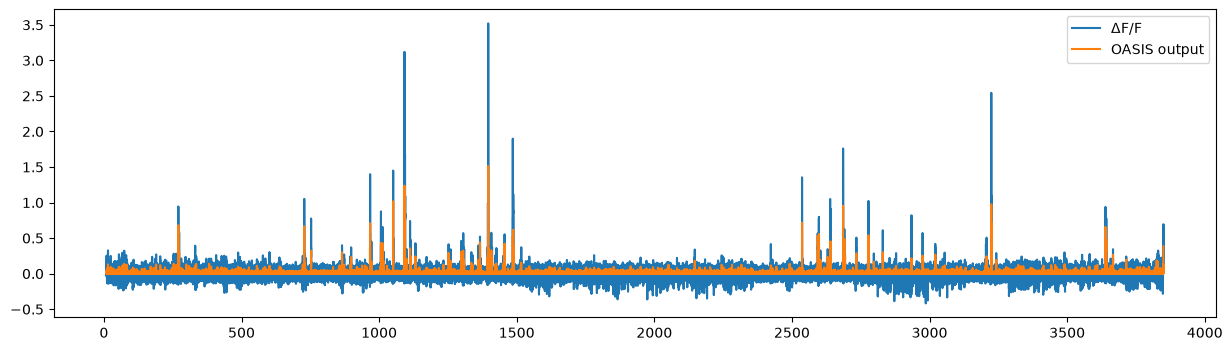

In [8]:
plt.figure(figsize=(15, 4))

plt.plot(session["t"], session["dff"][0], label="ΔF/F")
plt.plot(session["t"], session["spikes"][0], label="OASIS output")

plt.legend()

## 2. Filter running traces and extract running times

In [9]:
data = load_saved_data("data_with_spikes")

In [ ]:
def preprocess_running_speed(
    data: dict,
    high: float = 3.0,
    order: int = 3,
    clip_speed: bool = True,
    running_threshold: float = 2.0,
    ) -> dict:

    for name, session in data["sessions"].items():
        speed = np.asarray(session["running_speed"][0], dtype=float)
        t = np.asarray(session["running_speed"][1], dtype=float)
        dt = np.median(np.diff(t))

        fs = 1.0 / dt
        nyquist = 0.5 * fs
        if not (0 < high < nyquist):
            raise ValueError(f"{name}: high must be between 0 and {nyquist:.3f} Hz, got {high}")

        valid = np.isfinite(speed)

        # We have nans at beginning and end of the speed trace,
        # so we need to interpolate to fill them in before filtering.
        speed_interp = np.interp(
            np.arange(speed.size),
            np.flatnonzero(valid),
            speed[valid],
        )

        b, a = signal.butter(order, high, btype="low", fs=fs)
        speed_filtered = signal.filtfilt(b, a, speed_interp)

        # clip running speed at 0
        if clip_speed:
            speed_filtered = np.clip(speed_filtered, 0, None)

        # Separate filtered speed into two kinematic phases: still (0) vs running (1).
        phases = np.full(speed_filtered.shape, -1, dtype=int)
        phases[speed_filtered <= running_threshold] = 0
        phases[speed_filtered > running_threshold] = 1

        # Restore missing values in filtered signal while keeping phase=-1 for invalid points.
        speed_filtered[~valid] = np.nan
        phases[~valid] = -1
        session["running_speed_filtered"] = np.vstack([speed_filtered, t])
        session["running_speed_phase"] = phases

    return data

In [ ]:
data = preprocess_running_speed(data, high=5, order=3, clip_speed=True, running_threshold=5.0)

In [12]:
data["sessions"]["B"]["running_speed_phase"]

array([-1, -1, -1, ..., -1, -1, -1], shape=(113850,))

In [13]:
def plot_running_speed(data, session="B", t=(0, 100)):
    """Plot raw and filtered running speed with phase background blocks."""
    session_data = data["sessions"][session]

    speed_raw, time_raw = (np.asarray(a, dtype=float) for a in session_data["running_speed"])
    speed_filt, time_filt = (np.asarray(a, dtype=float) for a in session_data["running_speed_filtered"])

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axs[0].plot(time_raw, speed_raw, color="0.2", lw=0.8)
    axs[0].set(xlim=t, title="Original Running Speed", ylabel="Speed (cm/s)")

    axs[1].plot(time_filt, speed_filt, color="0.2", lw=0.8)
    axs[1].set(xlim=t, title="Filtered Running Speed", ylabel="Speed (cm/s)", xlabel="Time (s)")

    # Shade contiguous phase blocks on both subplots.

    phase = np.asarray(session_data["running_speed_phase"], dtype=int)
    
    phase_names = {-1: "Invalid", 0: "Still", 1: "Running"}
    phase_colors = {-1: "0.8", 0: "tab:blue", 1: "tab:red"}

    change_points = np.flatnonzero(np.diff(phase)) + 1 # get the indices where the phase changes
    block_starts = np.concatenate(([0], change_points))
    block_ends = np.concatenate((change_points, [phase.size]))

    seen_labels = set()
    for start, end in zip(block_starts, block_ends):
        p = phase[start]
        label = phase_names.get(p, f"Phase {p}") if p not in seen_labels else None
        seen_labels.add(p)
        for ax in axs:
            ax.axvspan(
                time_filt[start], time_filt[end - 1],
                color=phase_colors.get(p, "0.5"), alpha=0.2, label=label,
            )

    axs[1].legend(loc="upper right")
    fig.tight_layout()
    return fig, axs

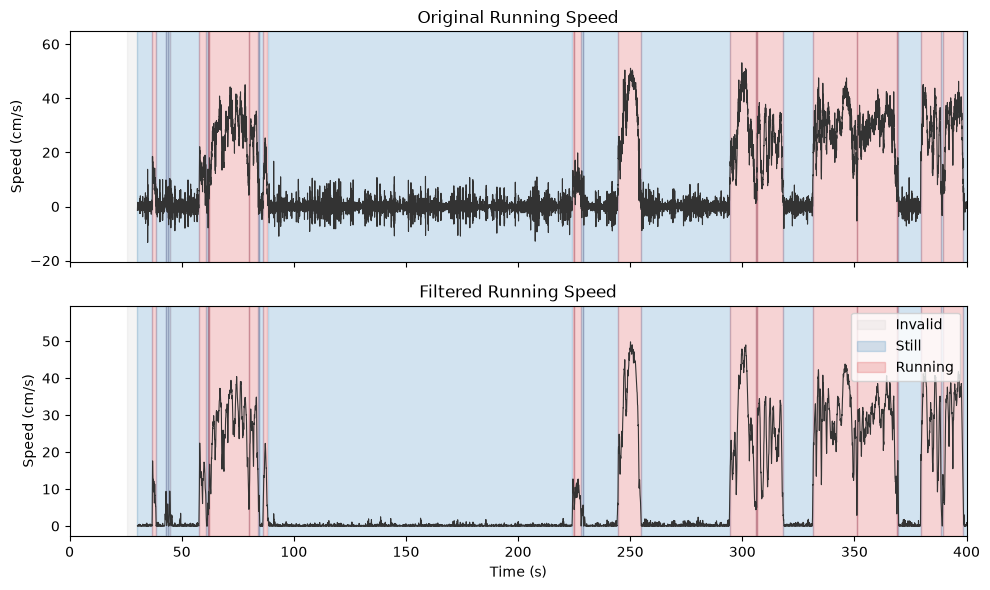

In [14]:
fig, axs = plot_running_speed(data, session="B", t=(0, 400))
plt.show()

In [15]:
# safe data 
save_data(data, "data_with_spikes_and_speed")